# Low-Rank RNNs for Decision Making and Working Memory

## Overview

This notebook examines how low-rank connectivity supports two tasks. A
rank-one RNN first integrates noisy evidence and stores a binary decision.
A rank-two RNN is then trained on a fixed-delay frequency-comparison task,
where it learns an oscillatory latent trajectory.

For each task, we evaluate behavior, inspect the latent dynamics, and fit a
Gaussian to the neuron loadings. The rank-two section ends with two direct
equivalent-circuit comparisons: one circuit uses the oscillatory RNN's
fitted loading covariance, while the other uses the covariances reported in
the paper. No RNN is initialized or trained from the paper covariances.

## Setup and notation

All experiments use the repository's `LowRankRNN`:

$$
\tau \dot{x}
= -x + \frac{1}{N}MN^\top \tanh(x) + Iu,
\qquad
z = \frac{1}{N}w^\top\tanh(x).
$$

The loading matrices $M,N\in\mathbb{R}^{N\times R}$ give a recurrent
matrix of rank at most $R$. We use $R=1$ or $R=2$, with
$\Delta t/\tau=20/100=0.2$. Only $M$ and $N$ are trained; the input
vector $I$ and readout $w$ remain fixed.

### Conventions

- A standard Gaussian average has prefactor $1/\sqrt{2\pi}$.
- The rank-one variance depends on the filtered input $v$, not the
  instantaneous input $u$.
- Mean-field $\kappa$ is the coefficient in
  $x\approx M\kappa+Iv$, computed with a pseudoinverse. It is not the
  unit-axis projection $m^\top x/\lVert m\rVert$.
- The reduced circuit includes a readout so that it can be evaluated on
  the same task as the trained RNN.

In [1]:
from math import ceil
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch

from low_rank_rnn import analysis, mean_field, plotting
from low_rank_rnn.data import perceptual_decision_making as decision_task
from low_rank_rnn.data import working_memory as memory_task
from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.training import decision_accuracy, train_model

plotting.set_plot_style()
BASE_SEED = 2026
NUM_UNITS = 512
TASK_MSE_THRESHOLD = 5e-3
NUM_GAUSSIAN_NETWORKS = 10
REPORT_FIGURE_DIRECTORY = Path("report/figures")


def save_report_figure(figure: plt.Figure, filename: str) -> Path:
    '''Save a notebook figure as a vector PDF for the LaTeX report.'''
    REPORT_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    output_path = REPORT_FIGURE_DIRECTORY / filename
    figure.savefig(output_path, format="pdf")
    return output_path

## 1. Rank-one perceptual decision task

### 1.1 Task

Each 75-step trial has a signed stimulus strength

$$
\bar{\mu} \in \pm 0.032\{1,2,4,8,16\},
\qquad
y=\operatorname{sign}(\bar{\mu}),
$$

with independent noise $\xi(t)\sim\mathcal{N}(0,0.03^2)$. The stimulus
is present for $5\leq t\leq45$, and the final 15 steps form the decision
window. The weakest stimulus is comparable to a single noise sample, so
the network must integrate evidence over time.

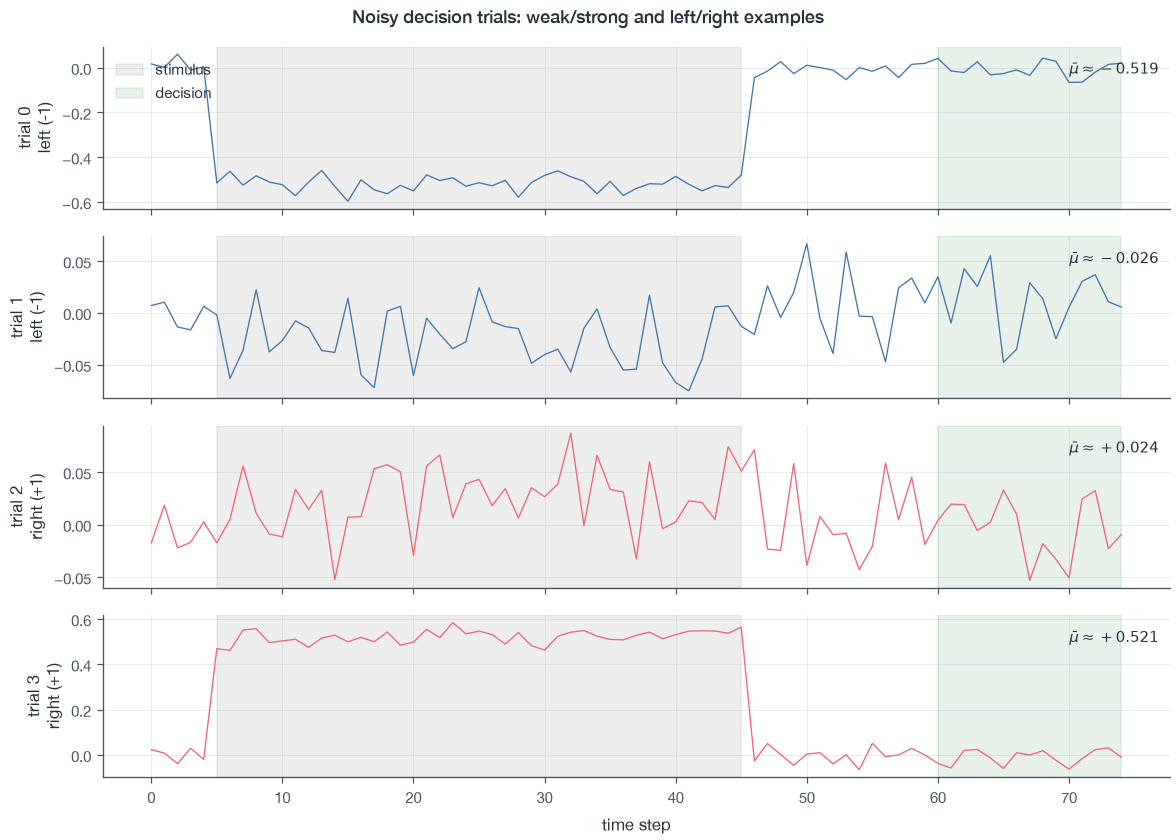

Allowed signed strengths: [-0.512 -0.256 -0.128 -0.064 -0.032  0.032  0.064  0.128  0.256  0.512]


In [2]:
preview_inputs, preview_labels = decision_task.generate_trials(
    num_trials=80,
    rng=np.random.default_rng(BASE_SEED),
)
preview_means = decision_task.mean_stimulus(preview_inputs)
preview_indices = decision_task.representative_trial_indices(
    preview_inputs,
    preview_labels,
)

rank1_decision_trials_figure, _ = plotting.plot_decision_trials(
    preview_inputs[preview_indices],
    preview_labels[preview_indices],
    mean_stimuli=preview_means[preview_indices],
)
save_report_figure(
    rank1_decision_trials_figure,
    "rank1-decision-task-trials.pdf",
)
plt.show()

print(
    "Allowed signed strengths:",
    np.round(np.sort(decision_task.STIMULUS_STRENGTHS), 3),
)


### 1.2 Train and evaluate

The recurrent update is computed as $m[n^\top\phi(x)/N]$, without
constructing the $N\times N$ matrix. Training uses Adam with learning
rate $5\times10^{-3}$, batches of 32, and MSE over the final 15 steps.
One epoch is one pass over the fixed training set.

In [3]:
RANK1_DECISION_STEPS = 15
RANK1_TRAIN_TRIALS = 200
RANK1_EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 5e-3

rank1_train_inputs, rank1_train_labels = decision_task.generate_trials(
    num_trials=RANK1_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED + 1),
)
rank1_test_inputs, rank1_test_labels = decision_task.generate_trials(
    num_trials=256,
    rng=np.random.default_rng(BASE_SEED + 2),
)

torch.manual_seed(BASE_SEED)
rank1_model = LowRankRNN(n_units=NUM_UNITS, rank=1)
fixed_input_before = rank1_model.I.clone()
fixed_readout_before = rank1_model.w.clone()
rank1_losses = train_model(
    rank1_model,
    torch.as_tensor(rank1_train_inputs, dtype=torch.float32),
    torch.as_tensor(rank1_train_labels, dtype=torch.float32),
    epochs=RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=RANK1_DECISION_STEPS,
    log_every=100,
)

# Orient the sign-indeterminate factors so positive latent activity maps
# to the +1 readout.
with torch.no_grad():
    m_centered = rank1_model.m[:, 0] - rank1_model.m[:, 0].mean()
    w_centered = rank1_model.w - rank1_model.w.mean()
    if torch.dot(m_centered, w_centered) < 0:
        rank1_model.m[:, 0].mul_(-1)
        rank1_model.n[:, 0].mul_(-1)

rank1_outputs, rank1_states = analysis.run_model(rank1_model, rank1_test_inputs)
rank1_decisions = analysis.decision_values(
    rank1_outputs,
    RANK1_DECISION_STEPS,
)
rank1_test_mse, _ = analysis.regression_metrics(
    rank1_decisions,
    rank1_test_labels,
)
rank1_accuracy = float(
    np.mean(np.where(rank1_decisions >= 0, 1, -1) == rank1_test_labels)
)
rank1_updates = RANK1_EPOCHS * ceil(RANK1_TRAIN_TRIALS / BATCH_SIZE)

assert rank1_losses[-1] < 5e-2
assert torch.equal(rank1_model.I, fixed_input_before)
assert torch.equal(rank1_model.w, fixed_readout_before)

print(f"Optimizer updates:      {rank1_updates}")
print(f"Final training loss:    {rank1_losses[-1]:.6f}  (target < 0.05)")
print(f"Held-out decision MSE: {rank1_test_mse:.6f}")
print(f"Held-out sign accuracy:{rank1_accuracy:8.1%}")


Epoch 100: loss=0.000164


Epoch 200: loss=0.000087


Epoch 300: loss=0.000069
Optimizer updates:      2100
Final training loss:    0.000069  (target < 0.05)
Held-out decision MSE: 0.000034
Held-out sign accuracy:  100.0%


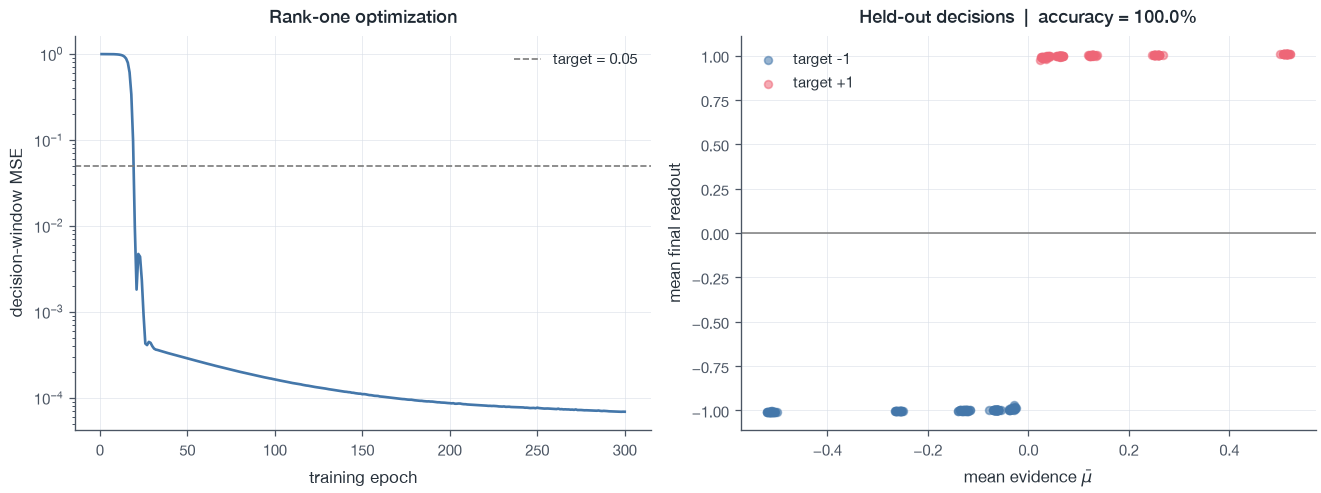

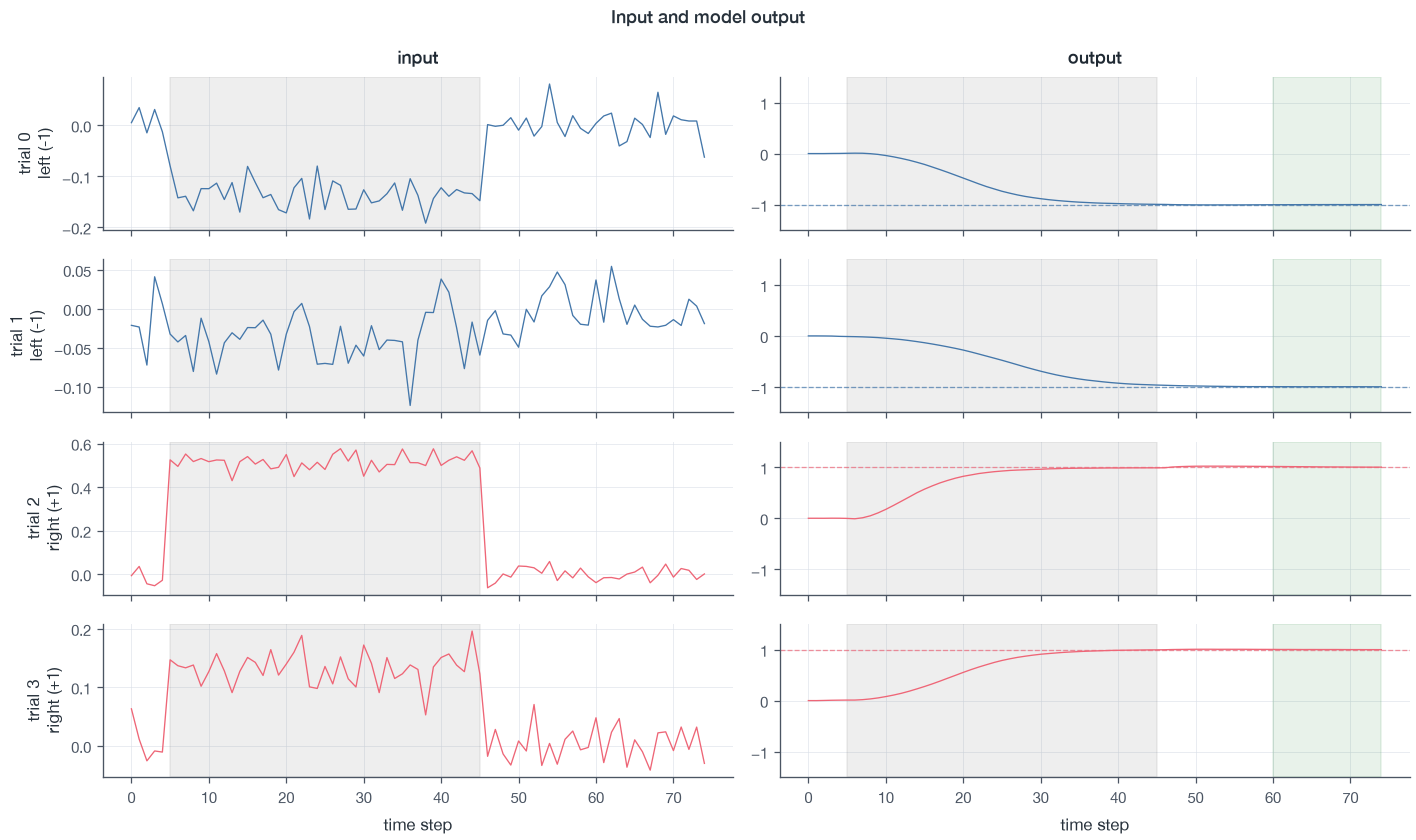

In [4]:
stimulus_estimates = decision_task.mean_stimulus(rank1_test_inputs)
rank1_training_summary_figure, _ = plotting.plot_decision_summary(
    rank1_losses,
    stimulus_estimates,
    rank1_decisions,
    rank1_test_labels,
    accuracy=rank1_accuracy,
    loss_threshold=5e-2,
)
save_report_figure(
    rank1_training_summary_figure,
    "rank1-training-summary.pdf",
)
plt.show()

positive_examples = np.flatnonzero(rank1_test_labels > 0)[:2]
negative_examples = np.flatnonzero(rank1_test_labels < 0)[:2]
rank1_examples = np.concatenate((negative_examples, positive_examples))
rank1_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_examples],
    rank1_test_labels[rank1_examples],
    rank1_outputs[rank1_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_input_output_figure,
    "rank1-input-output-examples.pdf",
)
plt.show()

rank1_training_examples = np.concatenate((positive_examples, negative_examples))
rank1_training_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_training_examples],
    rank1_test_labels[rank1_training_examples],
    rank1_outputs[rank1_training_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_training_input_output_figure,
    "rank1-training-input-output.pdf",
)
plt.close(rank1_training_input_output_figure)


### 1.3 Connectivity in loading space

Each neuron is one point in four-dimensional loading space
$(I,n,m,w)$. Three covariances connect input to output:

1. $\operatorname{Cov}(n,I)$ couples the input to the recurrent latent.
2. $\operatorname{Cov}(m,n)$ provides recurrent feedback.
3. $\operatorname{Cov}(m,w)$ couples the latent to the readout.

The rank-one factorization has an arbitrary sign:
$m\to-m,\ n\to-n$ leaves $J=mn^\top/N$ unchanged. We orient the
factors so that $\operatorname{Cov}(m,w)>0$; this makes positive latent
activity correspond to the $+1$ choice.

The handout uses
$(\sigma_{mn},\sigma_{nI},\sigma_{mw})=(1.4,2.6,2.1)$. This trained
network gives approximately $(1.59,0.56,2.22)$: recurrent and readout
coupling are similar, while the fitted input coupling is weaker.

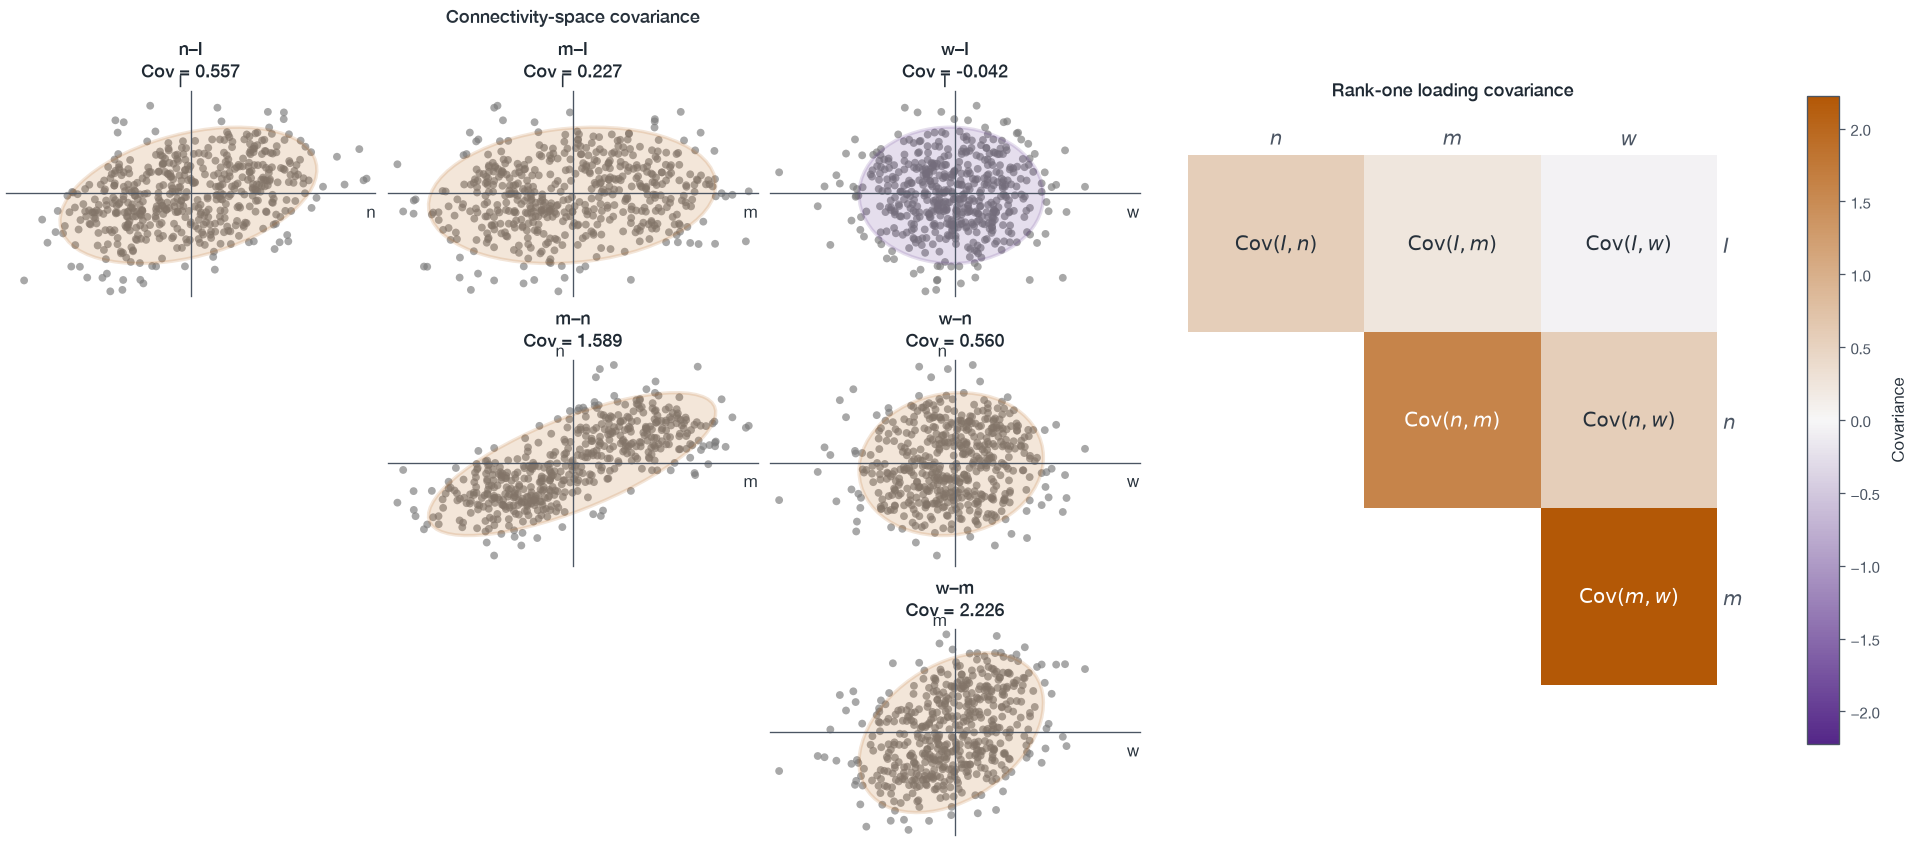

{'Cov(n, I)': 0.55559180843174,
 'Cov(m, n)': 1.586221464696318,
 'Cov(m, w)': 2.22194114418914}

In [5]:
rank1_vectors = analysis.connectivity_vectors(rank1_model)
rank1_names = tuple(rank1_vectors)
rank1_loading_mean, rank1_loading_covariance = analysis.fit_loading_gaussian(
    rank1_vectors
)

rank1_loading_space_figure, _, _ = plotting.plot_connectivity_summary(
    rank1_vectors,
    rank1_names,
    rank1_loading_covariance,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
    covariance_title="Rank-one loading covariance",
)
save_report_figure(
    rank1_loading_space_figure,
    "rank1-loading-space-covariance.pdf",
)
plt.show()

rank1_couplings = analysis.named_covariances(
    rank1_names,
    rank1_loading_covariance,
    (("n", "I"), ("m", "n"), ("m", "w")),
)
rank1_couplings


### 1.4 Gaussian resampling

We fit a four-dimensional Gaussian to the 512 neuron loadings and sample
ten new, untrained networks. This tests whether the fitted loading
statistics are sufficient for the task. At finite $N$, a sample only
approximates the fitted covariance, so performance can vary across draws.

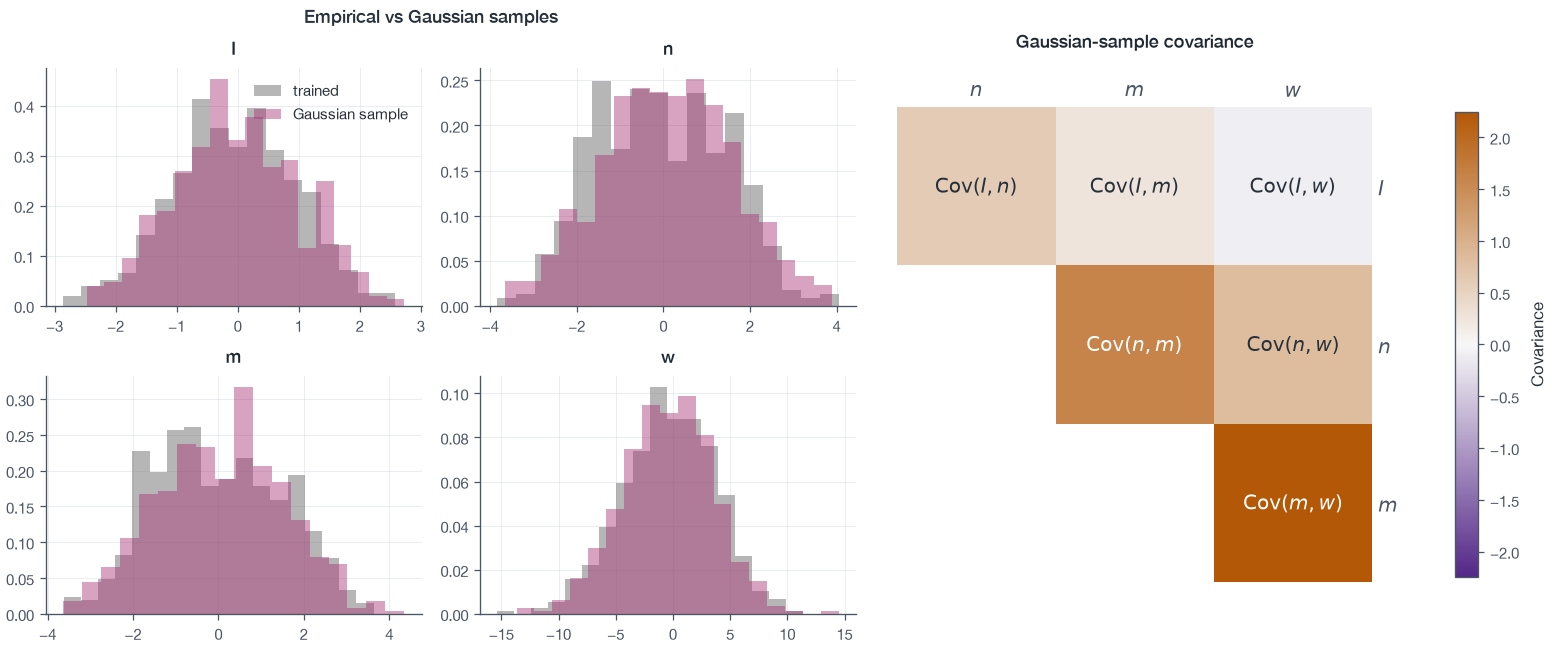

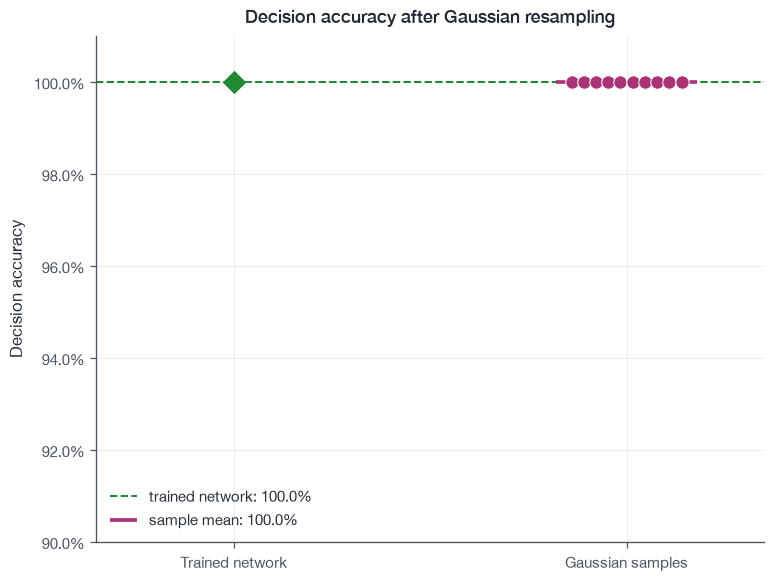

One-sample relative covariance error: 3.8%
Gaussian-network accuracy, mean [range]: 100.0% [100.0%, 100.0%]


In [6]:
rank1_sampled_vectors, rank1_sampled_covariance = (
    analysis.sample_loading_vectors(
        rank1_names,
        rank1_loading_mean,
        rank1_loading_covariance,
        num_samples=NUM_UNITS,
        rng=np.random.default_rng(BASE_SEED + 10),
    )
)
rank1_sampled_networks = analysis.sample_low_rank_rnns(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 11),
)
rank1_sampled_accuracies = np.array(
    [
        decision_accuracy(
            network,
            torch.as_tensor(rank1_test_inputs, dtype=torch.float32),
            torch.as_tensor(rank1_test_labels),
            decision_steps=RANK1_DECISION_STEPS,
        )
        for network in rank1_sampled_networks
    ]
)
rank1_covariance_error = np.linalg.norm(
    rank1_sampled_covariance - rank1_loading_covariance
) / np.linalg.norm(rank1_loading_covariance)

plotting.plot_gaussian_sampling_summary(
    rank1_vectors,
    rank1_sampled_vectors,
    rank1_names,
    rank1_sampled_covariance,
    rank1_accuracy,
    rank1_sampled_accuracies,
    covariance_title="Gaussian-sample covariance",
)
plt.show()

print(f"One-sample relative covariance error: {rank1_covariance_error:.1%}")
print(
    "Gaussian-network accuracy, mean [range]: "
    f"{rank1_sampled_accuracies.mean():.1%} "
    f"[{rank1_sampled_accuracies.min():.1%}, {rank1_sampled_accuracies.max():.1%}]"
)


### 1.5 Low-dimensional activity

Starting from $x(0)=0$, the state cannot leave
$\operatorname{span}\{m,I\}$: recurrence points along $m$, input along
$I$, and the leak adds no new direction. The activity should therefore
be at most two-dimensional.

We check this with PCA on the centered state matrix. The first plot shows
explained variance; the second projects the trial trajectories onto the
first two principal components. PCA may rotate the axes within the plane,
so the components need not align with $m$ and $I$ separately.

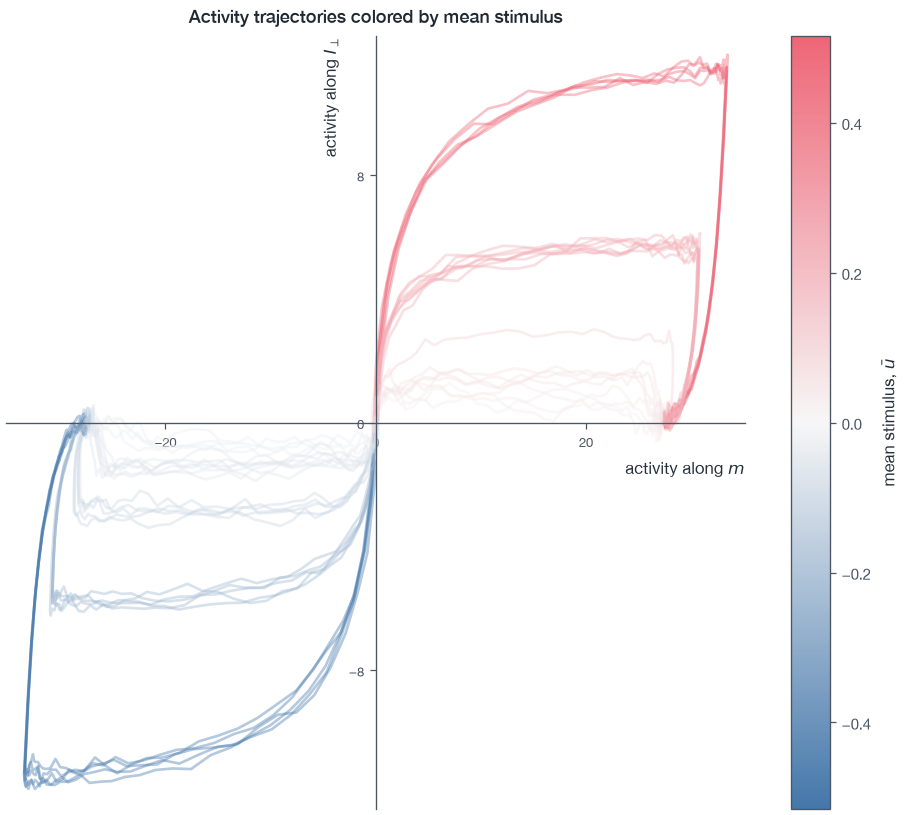

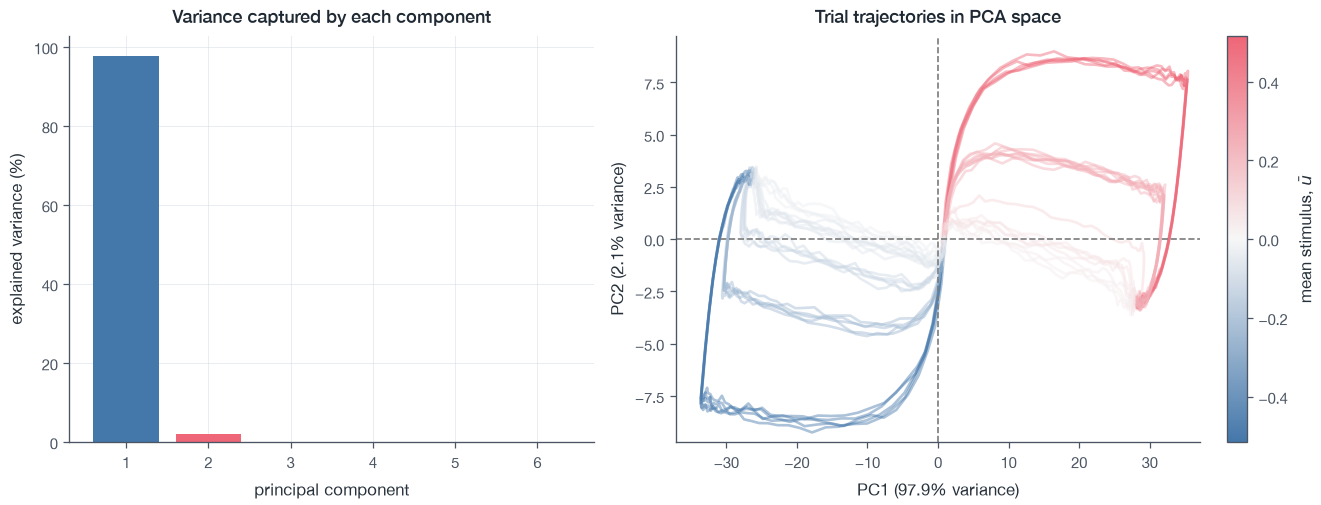

Variance explained by the first two PCs: 100.00%


In [7]:
rank1_projected = analysis.project_rank_one_activity(
    torch.as_tensor(rank1_states, dtype=torch.float32),
    rank1_model,
)
trajectory_subset = np.linspace(0, len(rank1_projected) - 1, 48, dtype=int)
rank1_latent_trajectories_figure, _ = (
    plotting.plot_activity_trajectories_by_stimulus(
        rank1_projected[trajectory_subset],
        stimulus_estimates[trajectory_subset],
    )
)
save_report_figure(
    rank1_latent_trajectories_figure,
    "rank1-latent-trajectories.pdf",
)
plt.show()

(
    rank1_explained_variance,
    _,
    rank1_pca_trajectories,
) = analysis.principal_component_analysis(rank1_states)
rank1_pca_summary_figure, _ = plotting.plot_pca_summary(
    rank1_explained_variance,
    rank1_pca_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
save_report_figure(
    rank1_pca_summary_figure,
    "rank1-pca-summary.pdf",
)
plt.show()
print(
    "Variance explained by the first two PCs: "
    f"{rank1_explained_variance[:2].sum():.2%}"
)


### 1.6 Gaussian mean-field reduction

For jointly Gaussian loadings and

$$
h_i = I_i v+\sum_r m_{ir}\kappa_r,
$$

Stein's lemma gives the latent dynamics, in units of $\tau$,

$$
\dot{\boldsymbol{\kappa}}
=-\boldsymbol{\kappa}
+\boldsymbol{\mu}_n\langle\tanh h\rangle
+\operatorname{Cov}(\boldsymbol{n},h)
  \langle\operatorname{sech}^2 h\rangle,
\qquad
\dot v=-v+u.
$$

The readout has the same form with $n$ replaced by $w$. For
zero-mean, orthogonal rank-one loadings this becomes

$$
\dot\kappa=-\kappa+g(\Delta)
\left[\sigma_{mn}\kappa+\sigma_{nI}v\right],
\qquad
\Delta^2=\sigma_m^2\kappa^2+\sigma_I^2v^2.
$$

The implementation keeps the fitted means and the full covariance, and
the same function is used for rank two.

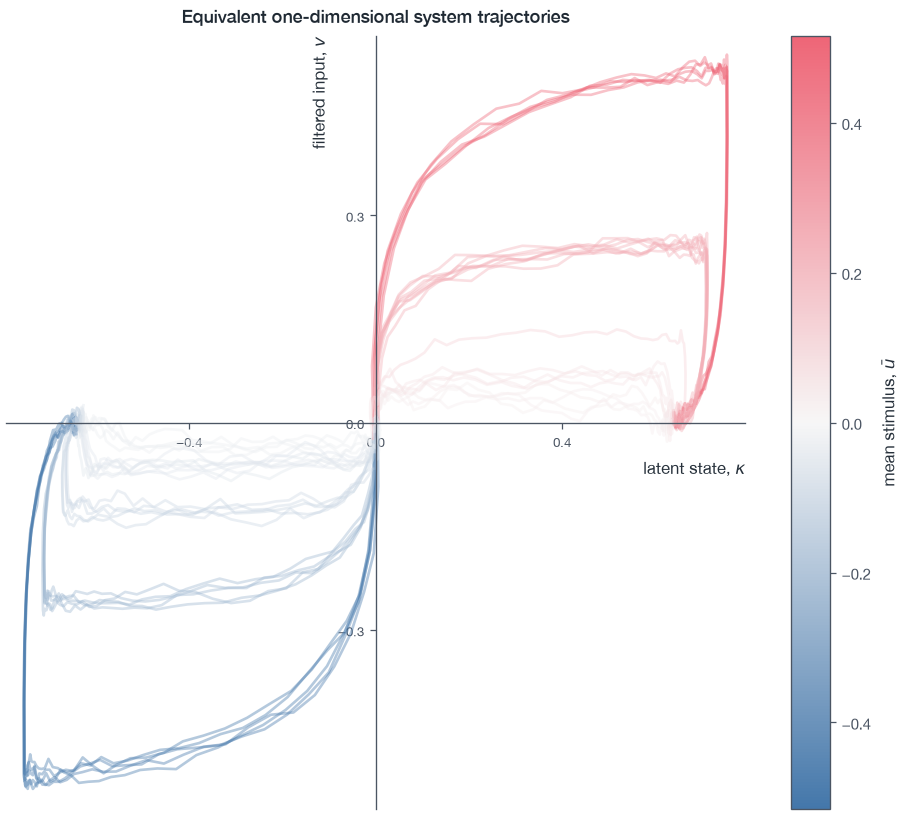

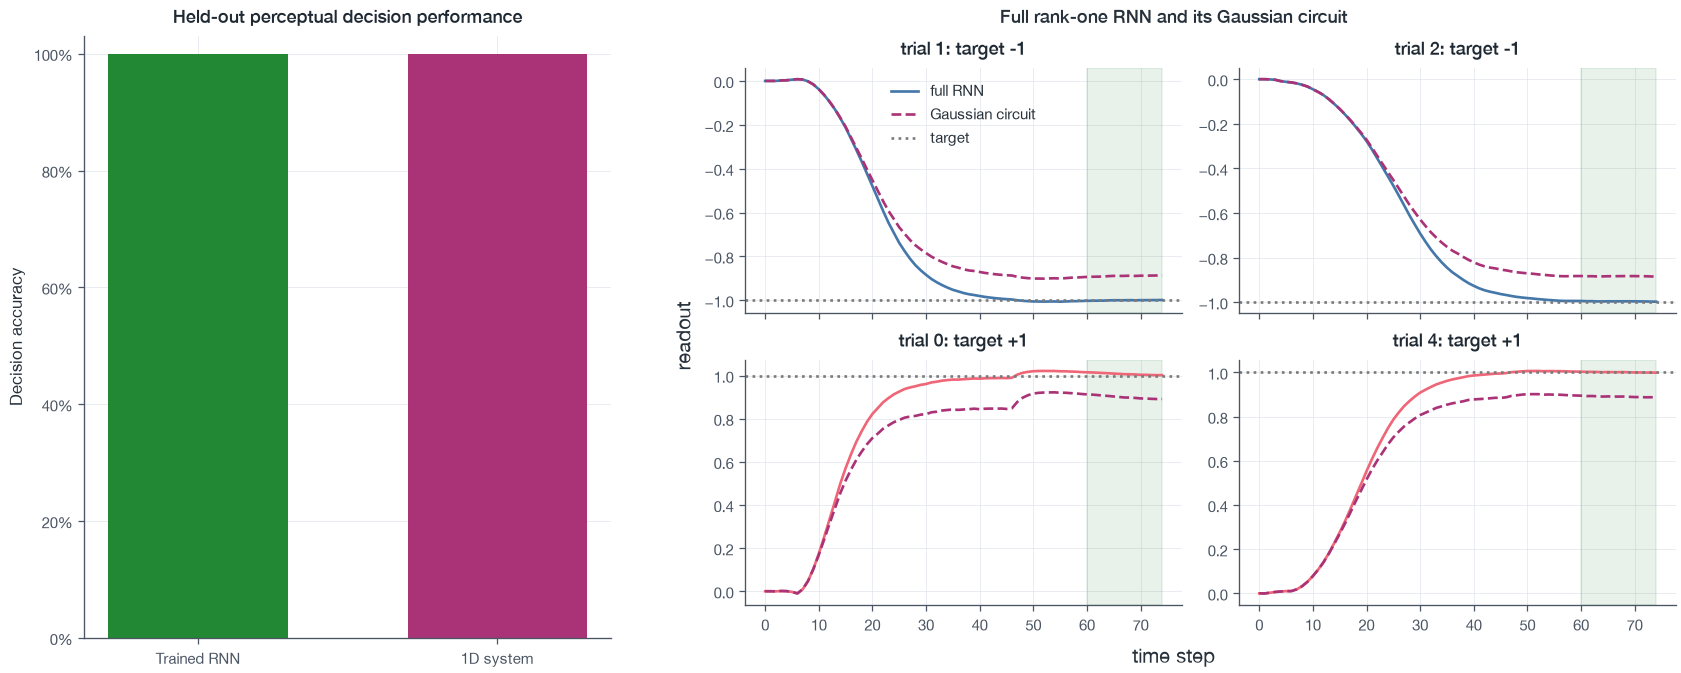

Gaussian-circuit sign accuracy: 100.0%


In [8]:
(
    rank1_reduced_outputs,
    rank1_reduced_kappa,
    rank1_filtered_input,
) = mean_field.simulate_gaussian_circuit(
    rank1_test_inputs,
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    step_size=rank1_model.step_size,
)
rank1_reduced_decisions = analysis.decision_values(
    rank1_reduced_outputs,
    RANK1_DECISION_STEPS,
)
rank1_reduced_accuracy = float(
    np.mean(
        np.where(rank1_reduced_decisions >= 0, 1, -1)
        == rank1_test_labels
    )
)

reduced_trajectories = np.dstack(
    (rank1_reduced_kappa[..., 0], rank1_filtered_input)
)
plotting.plot_reduced_system_trajectories(
    reduced_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()
rank1_reduced_summary_figure = plt.figure(figsize=(14, 5.6), layout="constrained")
accuracy_panel, comparison_panel = rank1_reduced_summary_figure.subfigures(
    1,
    2,
    width_ratios=(1, 1.65),
    wspace=0.06,
)
plotting.plot_reduced_system_accuracy(
    rank1_accuracy,
    rank1_reduced_accuracy,
    axis=accuracy_panel.subplots(),
)
plotting.plot_output_comparison(
    rank1_outputs,
    rank1_reduced_outputs,
    rank1_test_labels,
    rank1_examples,
    decision_steps=RANK1_DECISION_STEPS,
    axes=comparison_panel.subplots(2, 2, sharex=True),
)
plt.show()

print(f"Gaussian-circuit sign accuracy: {rank1_reduced_accuracy:.1%}")


### 1.7 Fixed points

At zero input, let $f(\kappa)=\dot\kappa$. We locate roots of
$f$ from a dense grid and classify each one by its slope:
$f'(\kappa)<0$ is stable and $f'(\kappa)>0$ is unstable.

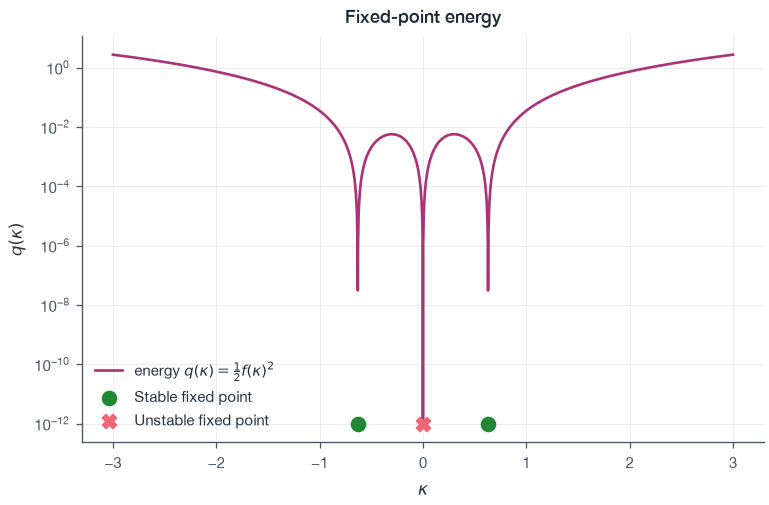

kappa=-0.6304  slope=-0.571  stable
kappa=+0.0000  slope=+0.587  unstable
kappa=+0.6304  slope=-0.571  stable


In [9]:
(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
) = mean_field.rank_one_fixed_points(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)
fixed_point_stability = np.where(
    fixed_point_slopes < 0,
    "stable",
    "unstable",
)
fixed_point_residuals = mean_field.gaussian_latent_flow(
    fixed_points[:, None],
    np.zeros(len(fixed_points)),
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)[:, 0]
assert np.max(np.abs(fixed_point_residuals)) < 1e-5

plotting.plot_fixed_points(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
)
plt.show()

for point, slope, stability in zip(
    fixed_points,
    fixed_point_slopes,
    fixed_point_stability,
):
    print(f"kappa={point:+.4f}  slope={slope:+.3f}  {stability}")


Two stable fixed points store the two choices, with an unstable boundary
between them. An exact-value integrator would instead require a continuum
of marginal fixed points so that the stimulus magnitude, not only its
sign, could persist.

## 2. Rank-two working-memory task

The rank-two RNN learns the normalized frequency difference

$$
y=\frac{f_1-f_2}{24}
$$

from a fixed sequence of two stimuli. We evaluate its behavior, identify
the oscillatory latent modes, and fit its post-training loading Gaussian.
We then compare two equivalent circuits on exactly the same inputs:

- the full-covariance circuit fitted from the oscillatory RNN;
- the zero-mean circuit specified by the paper covariances.

### 2.1 Task

The task uses all $7\times7$ ordered frequency pairs from 10 to 34 Hz.
The final five steps form the decision window.

In [10]:
MEMORY_DECISION_STEPS = memory_task.FIXED_DECISION_STEPS
MEMORY_TRIAL_LENGTH = memory_task.FIXED_TRIAL_STEPS
memory_grid_pairs = memory_task.frequency_pair_grid()
memory_grid_inputs, memory_grid_targets = memory_task.make_fixed_delay_trials(
    memory_grid_pairs
)
target_matrix = memory_grid_targets.reshape(
    len(memory_task.FREQUENCIES),
    len(memory_task.FREQUENCIES),
)

outside_stimuli = np.ones(MEMORY_TRIAL_LENGTH, dtype=bool)
for start, stop in (
    memory_task.FIXED_FIRST_WINDOW,
    memory_task.FIXED_SECOND_WINDOW,
):
    outside_stimuli[start:stop] = False
assert memory_grid_inputs.shape == (49, MEMORY_TRIAL_LENGTH)
assert np.all(memory_grid_inputs[:, outside_stimuli] == 0)


### 2.2 Oscillatory RNN: fixed-delay training

#### Train and evaluate

Rank-two and rank-one models are trained on the same fixed-delay trials.
The rank-one model serves as a capacity control.

Epoch 200: loss=0.115592


Epoch 400: loss=0.004947


Epoch 600: loss=0.000391


Oscillatory rank-two MSE: 0.000373
Matched rank-one MSE:   0.111737


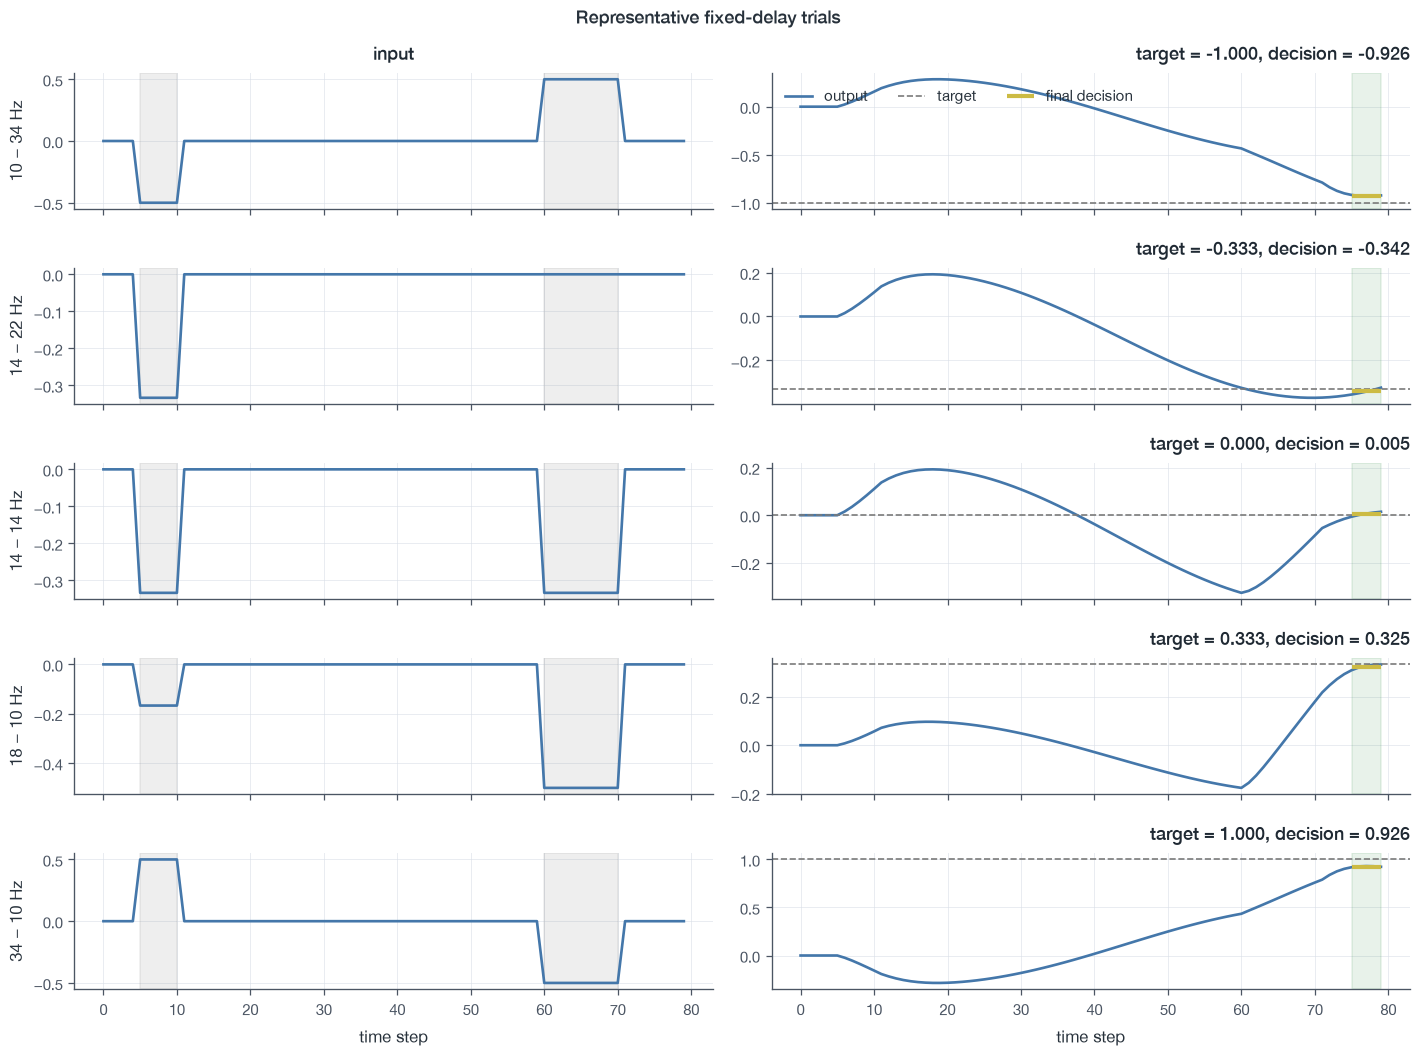

In [11]:
MEMORY_TRAIN_TRIALS = 200
MEMORY_RANK2_EPOCHS = 600
MEMORY_RANK1_EPOCHS = 600

_, memory_train_inputs, memory_train_targets = (
    memory_task.sample_fixed_delay_trials(
        MEMORY_TRAIN_TRIALS,
        rng=np.random.default_rng(BASE_SEED),
    )
)

torch.manual_seed(BASE_SEED)
oscillatory_model = LowRankRNN(NUM_UNITS, rank=2)
oscillatory_losses = train_model(
    oscillatory_model,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK2_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=200,
)

torch.manual_seed(BASE_SEED + 1)
fixed_rank1_control = LowRankRNN(NUM_UNITS, rank=1)
fixed_rank1_losses = train_model(
    fixed_rank1_control,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=None,
)

oscillatory_grid_outputs, _ = analysis.run_model(
    oscillatory_model,
    memory_grid_inputs,
)
oscillatory_grid_decisions = analysis.decision_values(
    oscillatory_grid_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_mse, _ = analysis.regression_metrics(
    oscillatory_grid_decisions,
    memory_grid_targets,
)

fixed_rank1_outputs, _ = analysis.run_model(
    fixed_rank1_control,
    memory_grid_inputs,
)
fixed_rank1_decisions = analysis.decision_values(
    fixed_rank1_outputs,
    MEMORY_DECISION_STEPS,
)
fixed_rank1_mse, _ = analysis.regression_metrics(
    fixed_rank1_decisions,
    memory_grid_targets,
)

assert oscillatory_mse < TASK_MSE_THRESHOLD
print(f"Oscillatory rank-two MSE: {oscillatory_mse:.6f}")
print(f"Matched rank-one MSE:   {fixed_rank1_mse:.6f}")

representative_pairs = np.array(
    ((10, 34), (14, 22), (14, 14), (18, 10), (34, 10))
)
representative_inputs, representative_targets = (
    memory_task.make_fixed_delay_trials(representative_pairs)
)
representative_outputs, _ = analysis.run_model(
    oscillatory_model,
    representative_inputs,
)
plotting.plot_memory_trials(
    representative_pairs,
    representative_inputs,
    representative_targets,
    representative_outputs,
    first_window=memory_task.FIXED_FIRST_WINDOW,
    second_window=memory_task.FIXED_SECOND_WINDOW,
    decision_steps=MEMORY_DECISION_STEPS,
)
plt.show()


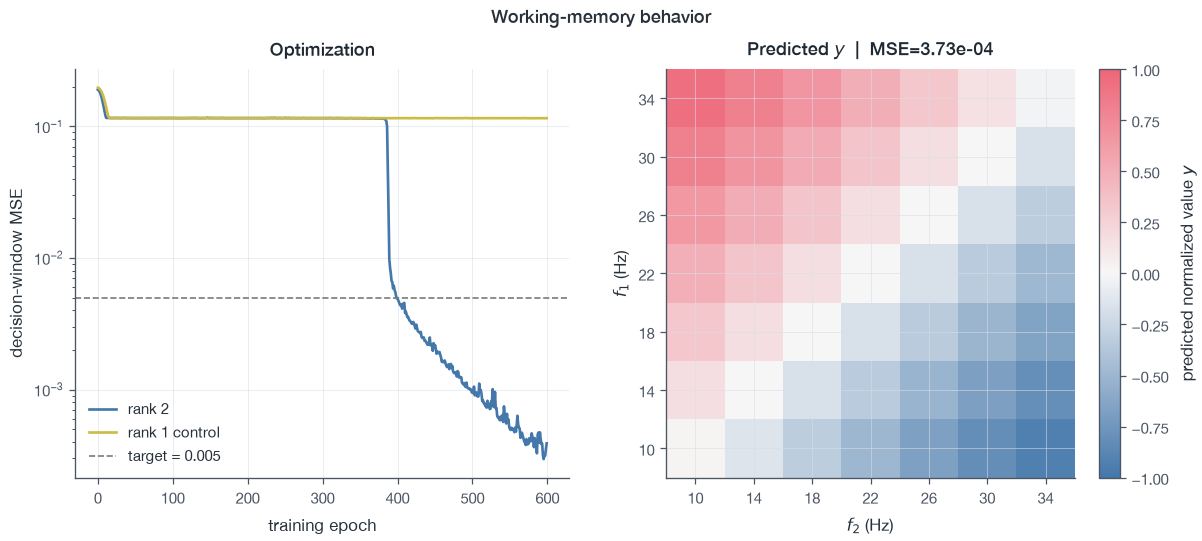

In [12]:
plotting.plot_memory_behavior(
    oscillatory_losses,
    fixed_rank1_losses,
    target_matrix,
    oscillatory_grid_decisions,
    memory_task.FREQUENCIES,
    mse=oscillatory_mse,
    loss_threshold=TASK_MSE_THRESHOLD,
)
plt.show()


#### Latent dynamics

We transform the rank-two RNN to an SVD basis, which preserves $MN^\top$,
and inspect the recurrent overlap eigenvalues and projected trajectories.

In [13]:
oscillatory_canonical, oscillatory_reconstruction_error = (
    analysis.svd_canonical_model(oscillatory_model)
)
oscillatory_m = oscillatory_canonical.m.detach().numpy()
oscillatory_n = oscillatory_canonical.n.detach().numpy()
oscillatory_overlap_eigenvalues = np.linalg.eigvals(
    analysis.connectivity_overlap(oscillatory_m, oscillatory_n)
)

assert oscillatory_reconstruction_error < 1e-5
print(
    "Recurrent overlap eigenvalues:",
    np.round(oscillatory_overlap_eigenvalues, 3),
)


Recurrent overlap eigenvalues: [1.041+0.282j 1.041-0.282j]


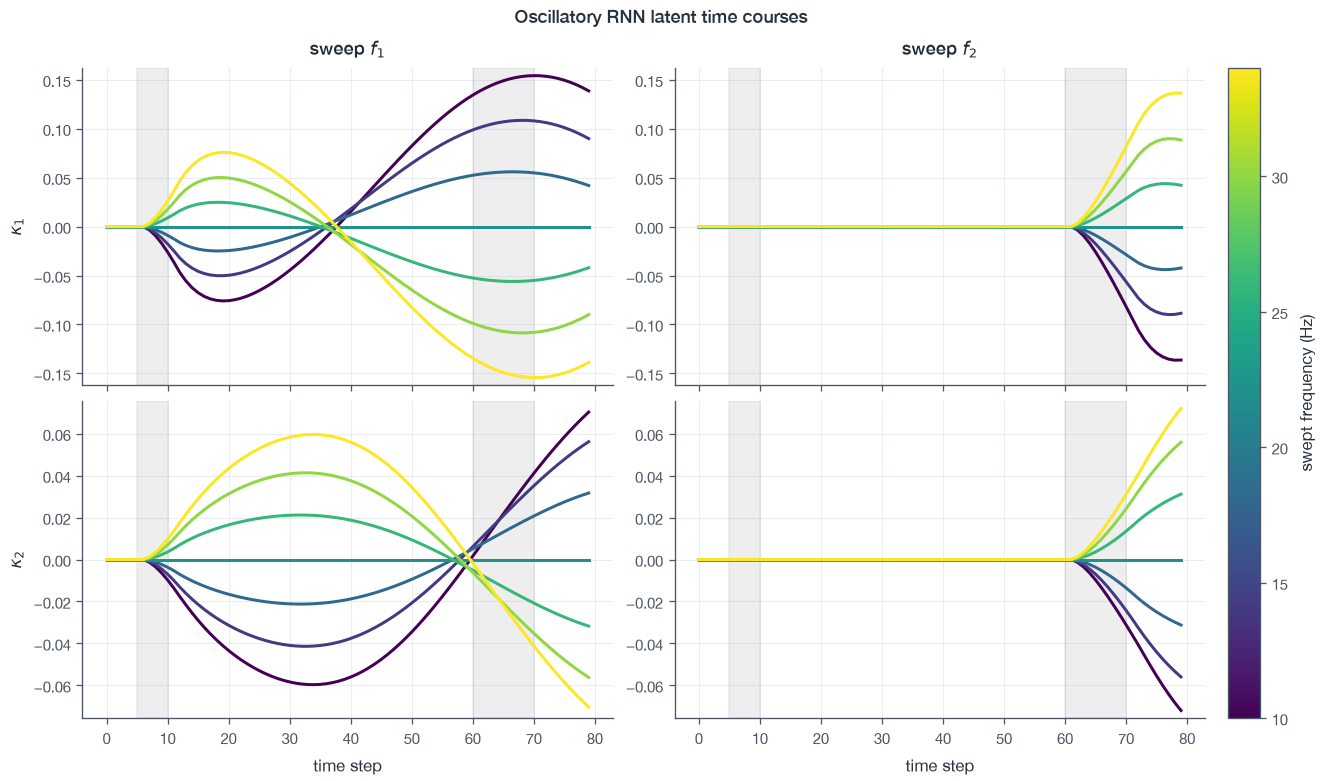

In [14]:
first_sweep_pairs, second_sweep_pairs = memory_task.frequency_sweeps()
first_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    first_sweep_pairs
)
second_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    second_sweep_pairs
)
oscillatory_basis = np.column_stack(
    (oscillatory_m, oscillatory_canonical.I.detach().numpy())
)
_, first_sweep_states, first_sweep_coordinates = (
    analysis.simulate_and_project(
        oscillatory_canonical,
        first_sweep_inputs,
        oscillatory_basis,
    )
)
_, _, second_sweep_coordinates = analysis.simulate_and_project(
    oscillatory_canonical,
    second_sweep_inputs,
    oscillatory_basis,
)

plotting.plot_latent_sweeps(
    first_sweep_coordinates[..., :2],
    second_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=np.arange(MEMORY_TRIAL_LENGTH),
    window_spans=(
        (
            memory_task.FIXED_FIRST_WINDOW[0],
            memory_task.FIXED_FIRST_WINDOW[1] - 1,
        ),
        (
            memory_task.FIXED_SECOND_WINDOW[0],
            memory_task.FIXED_SECOND_WINDOW[1] - 1,
        ),
    ),
    column_titles=(r"sweep $f_1$", r"sweep $f_2$"),
    row_labels=(r"$\kappa_1$", r"$\kappa_2$"),
    title="Oscillatory RNN latent time courses",
)
plt.show()


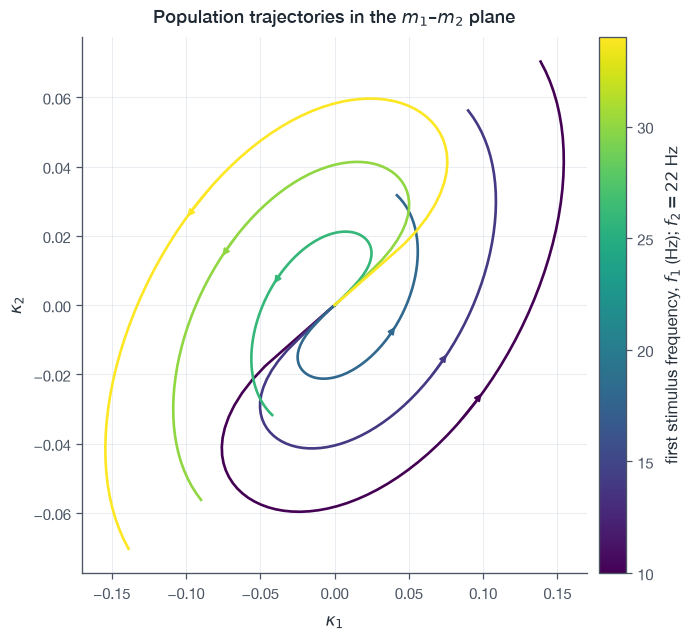

Median delay-flow eigenvalues (1/tau): [0.029 0.029]


In [15]:
plotting.plot_latent_plane(
    first_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    colorbar_label=(
        r"first stimulus frequency, $f_1$ (Hz); $f_2=22$ Hz"
    ),
)
plt.show()

delay_probe_states = first_sweep_states[
    :, memory_task.FIXED_SECOND_WINDOW[0] - 1
]
delay_eigenvalues = analysis.latent_jacobian_eigenvalues(
    oscillatory_canonical,
    delay_probe_states,
)
median_delay_decay = np.median(
    np.sort(delay_eigenvalues.real, axis=1),
    axis=0,
)[::-1]
print(
    "Median delay-flow eigenvalues (1/tau):",
    np.round(median_delay_decay, 3),
)


The two latent coordinates oscillate out of phase. The overlap eigenvalues
$1.041\pm0.282i$, together with median delay-flow real parts of
$+0.029$, are consistent with a weakly expanding rotation at the probed
delay states. The trained RNN uses this rotation as a clock for the fixed
schedule.

#### Delay generalization

The RNN was trained only with a blank delay of 49 time steps. To test
whether it learned a general memory or a phase-specific solution, we move
the second stimulus and decision window together while preserving all
stimulus durations. At every delay, we evaluate all 49 ordered frequency
pairs and compute

$$
\operatorname{MSE}(d)
=\frac{1}{49}\sum_{i=1}^{49}
\left[\bar z_i(d)-y_i\right]^2,
$$

where $\bar z_i(d)$ is the readout averaged over the final five decision
steps. Extending the sweep over several rotations tests the stronger
prediction that performance should disappear and return periodically.

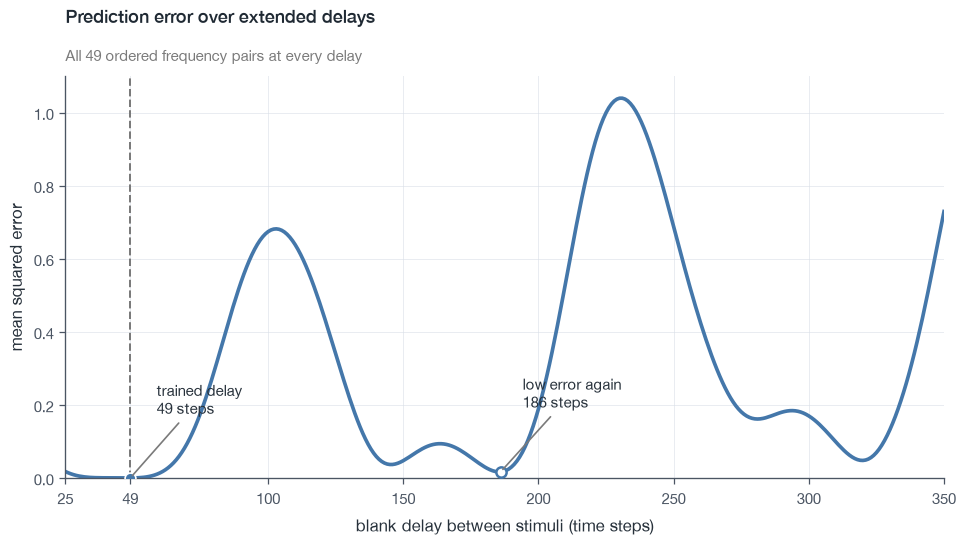

Trained delay (49 steps): MSE=0.000373
First low-error recurrence (186 steps): MSE=0.017099


In [16]:
extended_delay_steps = np.arange(25, 351)
trained_delay_steps = (
    memory_task.FIXED_SECOND_WINDOW[0]
    - memory_task.FIXED_FIRST_WINDOW[1]
)

network_delay_mses = []
for delay in extended_delay_steps:
    delayed_inputs, _ = memory_task.make_fixed_delay_trials(
        memory_grid_pairs,
        second_start=memory_task.FIXED_FIRST_WINDOW[1] + int(delay),
    )
    delayed_outputs, _ = analysis.run_model(
        oscillatory_model,
        delayed_inputs,
    )
    delayed_decisions = analysis.decision_values(
        delayed_outputs,
        MEMORY_DECISION_STEPS,
    )
    delay_mse, _ = analysis.regression_metrics(
        delayed_decisions,
        memory_grid_targets,
    )
    network_delay_mses.append(delay_mse)
network_delay_mses = np.asarray(network_delay_mses)

first_recurrence_window = (
    (extended_delay_steps >= 150)
    & (extended_delay_steps <= 225)
)
first_recurrence_delays = extended_delay_steps[
    first_recurrence_window
]
first_recurrence_mses = network_delay_mses[
    first_recurrence_window
]
first_recurrence_index = int(np.argmin(first_recurrence_mses))
first_recurrence_delay = int(
    first_recurrence_delays[first_recurrence_index]
)
first_recurrence_mse = float(
    first_recurrence_mses[first_recurrence_index]
)
trained_delay_mse = float(
    network_delay_mses[
        extended_delay_steps == trained_delay_steps
    ][0]
)
delay_mse_y_limit = max(
    0.5,
    np.ceil(network_delay_mses.max() * 10) / 10,
)

plotting.plot_delay_mse(
    extended_delay_steps,
    network_delay_mses,
    title="Prediction error over extended delays",
    reference_delay=trained_delay_steps,
    reference_label="trained delay",
    annotation_delays=(first_recurrence_delay,),
    annotation_labels=("low error again",),
    x_ticks=(25, 49, 100, 150, 200, 250, 300, 350),
    y_limit=delay_mse_y_limit,
)
plt.show()

print(f"Trained delay ({trained_delay_steps} steps): "
      f"MSE={trained_delay_mse:.6f}")
print(f"First low-error recurrence ({first_recurrence_delay} steps): "
      f"MSE={first_recurrence_mse:.6f}")

The error is phase-dependent rather than monotonic.
It rises by orders of magnitude as the remembered first stimulus rotates
away from the fixed readout direction, then falls to MSE $0.017$ at 186
steps. This is a strong recovery relative to the out-of-phase peaks, but
it does not fully regain the trained-delay MSE of $0.00037$ or the
$0.005$ task criterion. Later peaks and troughs drift and grow because the
learned rotation is weakly expanding and nonlinear. The repeated loss and
partial recovery of performance nevertheless links task behavior directly
to the oscillatory dynamics.

#### Gaussian reconstruction

We fit a six-dimensional Gaussian in the SVD basis, then test finite
$N=512$ samples and the full-covariance mean-field circuit on the
fixed-delay grid.

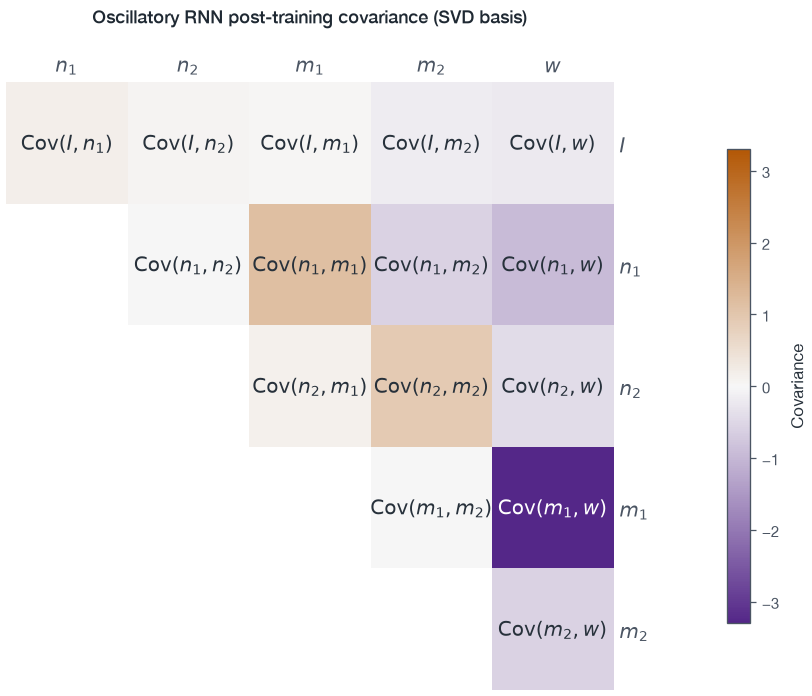

In [17]:
oscillatory_vectors = analysis.connectivity_vectors(
    oscillatory_canonical
)
oscillatory_names = tuple(oscillatory_vectors)
(
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
) = analysis.fit_loading_gaussian(oscillatory_vectors)

plotting.plot_connectivity_covariance(
    oscillatory_names,
    oscillatory_loading_covariance,
    title="Oscillatory RNN post-training covariance (SVD basis)",
)
plt.show()


In [18]:
oscillatory_sampled_networks = analysis.sample_low_rank_rnns(
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 21),
)
oscillatory_sampled_mses = analysis.network_regression_mses(
    oscillatory_sampled_networks,
    memory_grid_inputs,
    memory_grid_targets,
    decision_steps=MEMORY_DECISION_STEPS,
)

print(
    "Finite Gaussian RNN MSE, median [range]: "
    f"{np.median(oscillatory_sampled_mses):.4f} "
    f"[{oscillatory_sampled_mses.min():.4f}, "
    f"{oscillatory_sampled_mses.max():.4f}]"
)


Finite Gaussian RNN MSE, median [range]: 0.0839 [0.0044, 1.2020]


In [28]:
oscillatory_reduced_outputs, _, _ = mean_field.simulate_gaussian_circuit(
    memory_grid_inputs,
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
oscillatory_reduced_decisions = analysis.decision_values(
    oscillatory_reduced_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_reduced_mse, _ = (
    analysis.regression_metrics(
        oscillatory_reduced_decisions,
        memory_grid_targets,
    )
)

plotting.plot_gaussian_pipeline(
    oscillatory_mse,
    oscillatory_reduced_mse,
    oscillatory_sampled_mses,
    memory_grid_targets,
    oscillatory_grid_decisions,
    oscillatory_reduced_decisions,
    threshold=TASK_MSE_THRESHOLD,
    title="Gaussian re-sampling performance",
    score_label="MSE",
    readout_title="Readout grid",
)
plt.show()


NameError: name 'oscillatory_names' is not defined

Finite Gaussian samples vary widely (median MSE $0.0839$). The
full-covariance circuit preserves the trained RNN's decision ordering,
but its MSE of $0.0195$ still misses the $0.005$ task threshold.

### 2.3 Equivalent circuits from fitted and paper covariances

We now leave further RNN training out of scope and work only with the
two-dimensional equivalent circuit. The first parameter set is the fitted
mean and full covariance from the oscillatory RNN above. The second is a
zero-mean Gaussian construction whose six reported couplings are

$$
\sigma_{n_1m_1}=1,\quad
\sigma_{n_2m_2}=0.5,\quad
\sigma_{n_1I}=0.5,\quad
\sigma_{n_2I}=1.9,\quad
\sigma_{m_1w}=2.8,\quad
\sigma_{m_2w}=-2.2.
$$

For the paper circuit we use unit variances for $I,m_1,m_2$ and readout
variance $16$, matching the loading construction implied by those
coefficients. The resulting covariance is positive semidefinite and both
parameter sets are simulated by the same Gaussian mean-field equations.

In [20]:
paper_names = ("I", "n_1", "n_2", "m_1", "m_2", "w")
assert oscillatory_names == paper_names

# Rows are (I, n1, n2, m1, m2, w); columns are independent
# standard-normal sources (I, m1, m2, readout residual).
paper_readout_residual = np.sqrt(16 - 2.8**2 - 2.2**2)
paper_loading_transform = np.array(
    (
        (1.0, 0.0, 0.0, 0.0),
        (0.5, 1.0, 0.0, 0.0),
        (1.9, 0.0, 0.5, 0.0),
        (0.0, 1.0, 0.0, 0.0),
        (0.0, 0.0, 1.0, 0.0),
        (0.0, 2.8, -2.2, paper_readout_residual),
    )
)
paper_loading_mean = np.zeros(len(paper_names))
paper_loading_covariance = (
    paper_loading_transform @ paper_loading_transform.T
)
paper_couplings = analysis.named_covariances(
    paper_names,
    paper_loading_covariance,
    (
        ("n_1", "m_1"),
        ("n_2", "m_2"),
        ("n_1", "I"),
        ("n_2", "I"),
        ("m_1", "w"),
        ("m_2", "w"),
    ),
)

assert np.linalg.eigvalsh(paper_loading_covariance).min() > -1e-10
paper_couplings

{'Cov(n_1, m_1)': 1.0,
 'Cov(n_2, m_2)': 0.5,
 'Cov(n_1, I)': 0.5,
 'Cov(n_2, I)': 1.9,
 'Cov(m_1, w)': 2.8,
 'Cov(m_2, w)': -2.2}

#### Analysis 1: latent trajectories

We sweep the first frequency while holding the second at 22 Hz, then plot
the two circuit coordinates through the complete fixed-delay trial. The
same stimuli, integration step, and initial state are used for both
covariance parameter sets.

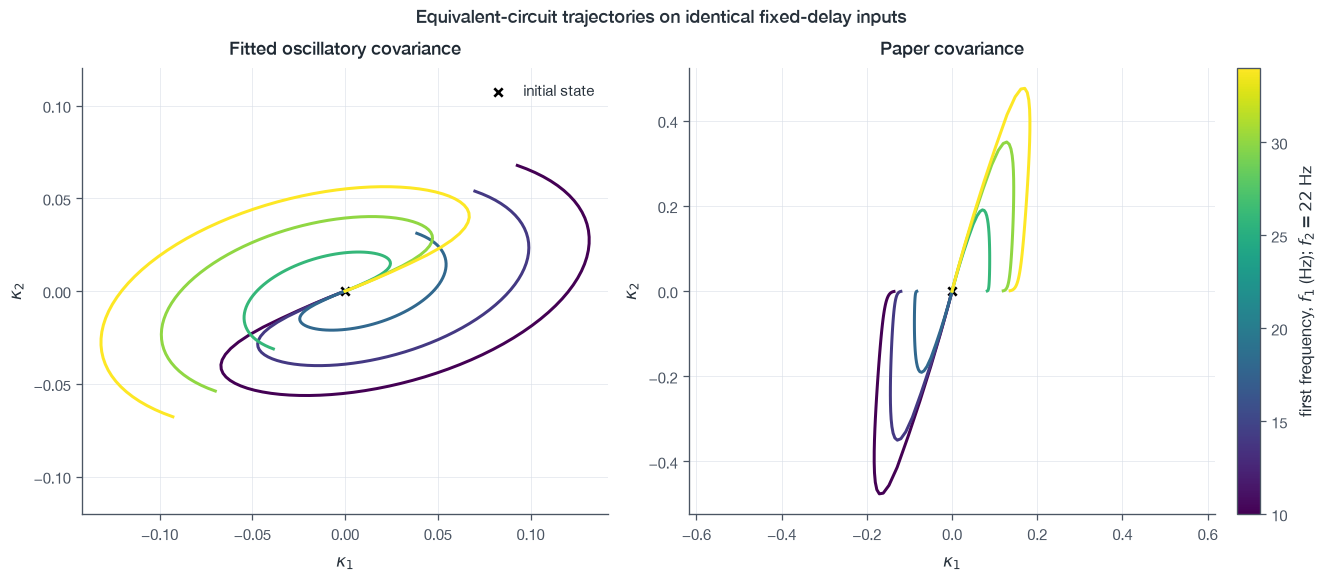

In [21]:
_, oscillatory_circuit_sweep, _ = mean_field.simulate_gaussian_circuit(
    first_sweep_inputs,
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
_, paper_circuit_sweep, _ = mean_field.simulate_gaussian_circuit(
    first_sweep_inputs,
    paper_names,
    paper_loading_mean,
    paper_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)

frequency_norm = mpl.colors.Normalize(
    memory_task.FREQUENCIES.min(),
    memory_task.FREQUENCIES.max(),
)
frequency_cmap = mpl.colormaps["viridis"]
circuit_trajectory_figure, circuit_trajectory_axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.8),
    constrained_layout=True,
)
for axis, trajectories, title in zip(
    circuit_trajectory_axes,
    (oscillatory_circuit_sweep, paper_circuit_sweep),
    ("Fitted oscillatory covariance", "Paper covariance"),
):
    for frequency, trajectory in zip(
        memory_task.FREQUENCIES,
        trajectories,
    ):
        axis.plot(
            trajectory[:, 0],
            trajectory[:, 1],
            color=frequency_cmap(frequency_norm(frequency)),
            linewidth=1.8,
        )
    axis.scatter(0, 0, color="black", marker="x", label="initial state")
    axis.set(
        xlabel=r"$\kappa_1$",
        ylabel=r"$\kappa_2$",
        title=title,
    )
    axis.set_aspect("equal", adjustable="datalim")

circuit_trajectory_axes[0].legend(loc="best")
circuit_trajectory_colorbar = circuit_trajectory_figure.colorbar(
    mpl.cm.ScalarMappable(norm=frequency_norm, cmap=frequency_cmap),
    ax=circuit_trajectory_axes,
    pad=0.02,
)
circuit_trajectory_colorbar.set_label(
    r"first frequency, $f_1$ (Hz); $f_2=22$ Hz"
)
circuit_trajectory_figure.suptitle(
    "Equivalent-circuit trajectories on identical fixed-delay inputs"
)
plt.show()

The fitted covariance produces a compact rotating trajectory, mirroring
the oscillatory geometry of the trained RNN. The paper covariance instead
produces larger, asymmetric excursions: the first mode changes slowly,
while the second responds more transiently. This is a covariance-level
comparison only; no second RNN is trained.

##### Paper circuit: persistent and transient mode time courses

To separate the modes explicitly, we sweep each stimulus frequency while
holding the other at 22 Hz. The upper row shows the slow $\kappa_1$ mode;
the lower row shows the faster $\kappa_2$ mode. Shading marks the two
stimulus windows.

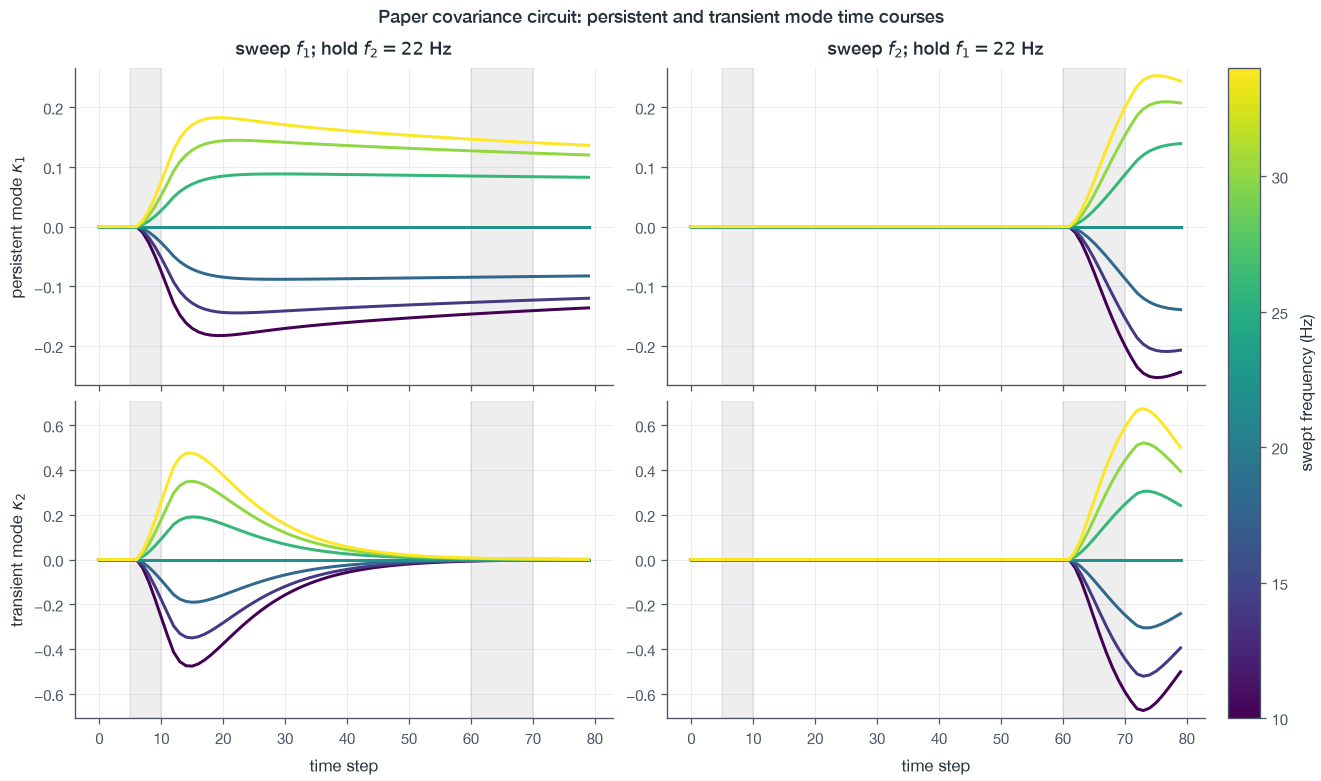

In [22]:
_, paper_circuit_second_sweep, _ = (
    mean_field.simulate_gaussian_circuit(
        second_sweep_inputs,
        paper_names,
        paper_loading_mean,
        paper_loading_covariance,
        step_size=oscillatory_canonical.step_size,
    )
)

paper_mode_time_course_figure, _ = plotting.plot_latent_sweeps(
    paper_circuit_sweep,
    paper_circuit_second_sweep,
    memory_task.FREQUENCIES,
    time_values=np.arange(MEMORY_TRIAL_LENGTH),
    window_spans=(
        (
            memory_task.FIXED_FIRST_WINDOW[0],
            memory_task.FIXED_FIRST_WINDOW[1] - 1,
        ),
        (
            memory_task.FIXED_SECOND_WINDOW[0],
            memory_task.FIXED_SECOND_WINDOW[1] - 1,
        ),
    ),
    column_titles=(
        r"sweep $f_1$; hold $f_2=22$ Hz",
        r"sweep $f_2$; hold $f_1=22$ Hz",
    ),
    row_labels=(
        r"persistent mode $\kappa_1$",
        r"transient mode $\kappa_2$",
    ),
    title=(
        "Paper covariance circuit: "
        "persistent and transient mode time courses"
    ),
)
plt.show()

The first mode carries the earlier stimulus across the blank delay, while
the second mode responds more strongly around stimulus transitions and
changes more quickly. The two rows therefore expose the slow/fast
separation that is compressed in the latent-plane plot above.

#### Analysis 2: fixed-delay task accuracy

Both circuits are evaluated on all 49 ordered frequency pairs. We report
the regression MSE and $R^2$ for the normalized difference, plus direction
accuracy on the 42 non-tie trials.

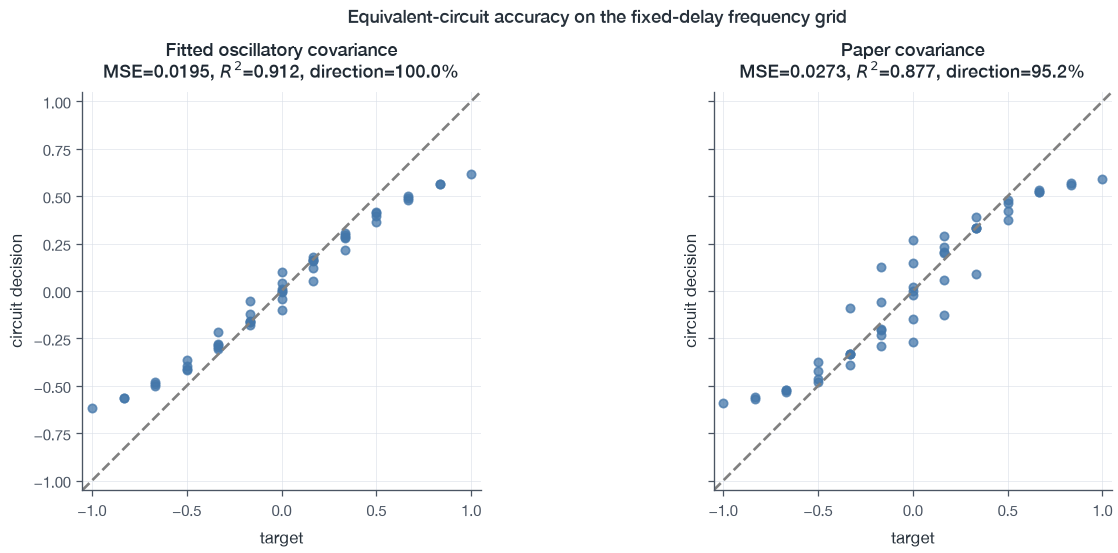

Fitted covariance — MSE / R² / direction accuracy: 0.019504 / 0.912 / 100.0%
Paper covariance  — MSE / R² / direction accuracy: 0.027342 / 0.877 / 95.2%


In [23]:
paper_circuit_outputs, _, _ = mean_field.simulate_gaussian_circuit(
    memory_grid_inputs,
    paper_names,
    paper_loading_mean,
    paper_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
paper_circuit_decisions = analysis.decision_values(
    paper_circuit_outputs,
    MEMORY_DECISION_STEPS,
)
paper_circuit_mse, paper_circuit_r_squared = analysis.regression_metrics(
    paper_circuit_decisions,
    memory_grid_targets,
)
_, oscillatory_circuit_r_squared = analysis.regression_metrics(
    oscillatory_reduced_decisions,
    memory_grid_targets,
)

non_tie_trials = memory_grid_targets != 0
oscillatory_circuit_direction_accuracy = np.mean(
    np.sign(oscillatory_reduced_decisions[non_tie_trials])
    == np.sign(memory_grid_targets[non_tie_trials])
)
paper_circuit_direction_accuracy = np.mean(
    np.sign(paper_circuit_decisions[non_tie_trials])
    == np.sign(memory_grid_targets[non_tie_trials])
)

circuit_accuracy_figure, circuit_accuracy_axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
decision_limit = 1.05 * max(
    np.abs(memory_grid_targets).max(),
    np.abs(oscillatory_reduced_decisions).max(),
    np.abs(paper_circuit_decisions).max(),
)
for axis, decisions, mse, r_squared, direction_accuracy, title in zip(
    circuit_accuracy_axes,
    (oscillatory_reduced_decisions, paper_circuit_decisions),
    (oscillatory_reduced_mse, paper_circuit_mse),
    (oscillatory_circuit_r_squared, paper_circuit_r_squared),
    (
        oscillatory_circuit_direction_accuracy,
        paper_circuit_direction_accuracy,
    ),
    ("Fitted oscillatory covariance", "Paper covariance"),
):
    axis.scatter(memory_grid_targets, decisions, alpha=0.75)
    axis.plot(
        (-decision_limit, decision_limit),
        (-decision_limit, decision_limit),
        color="gray",
        linestyle="--",
    )
    axis.set(
        xlim=(-decision_limit, decision_limit),
        ylim=(-decision_limit, decision_limit),
        xlabel="target",
        ylabel="circuit decision",
        title=(
            f"{title}\n"
            f"MSE={mse:.4f}, $R^2$={r_squared:.3f}, "
            f"direction={direction_accuracy:.1%}"
        ),
    )
    axis.set_aspect("equal", adjustable="box")

circuit_accuracy_figure.suptitle(
    "Equivalent-circuit accuracy on the fixed-delay frequency grid"
)
plt.show()

print(
    "Fitted covariance — MSE / R² / direction accuracy:",
    f"{oscillatory_reduced_mse:.6f} / "
    f"{oscillatory_circuit_r_squared:.3f} / "
    f"{oscillatory_circuit_direction_accuracy:.1%}",
)
print(
    "Paper covariance  — MSE / R² / direction accuracy:",
    f"{paper_circuit_mse:.6f} / "
    f"{paper_circuit_r_squared:.3f} / "
    f"{paper_circuit_direction_accuracy:.1%}",
)

The fitted covariance gives MSE $0.0195$, $R^2=0.912$, and $100\%$
direction accuracy. The paper covariance gives MSE $0.0273$, $R^2=0.877$,
and $95.2\%$ direction accuracy. Thus the fitted covariance is the closer
quantitative reconstruction of this trained RNN, while the paper
covariance remains a useful qualitative persistent/transient circuit.
Neither circuit meets the stricter $0.005$ regression threshold.

#### Analysis 3: extended-delay generalization

The paper covariance circuit is designed around persistent and transient
modes rather than a phase-specific rotating memory. We therefore evaluate
it on the same 25–350-step delay sweep and use the same MSE scale as the
RNN plot above.

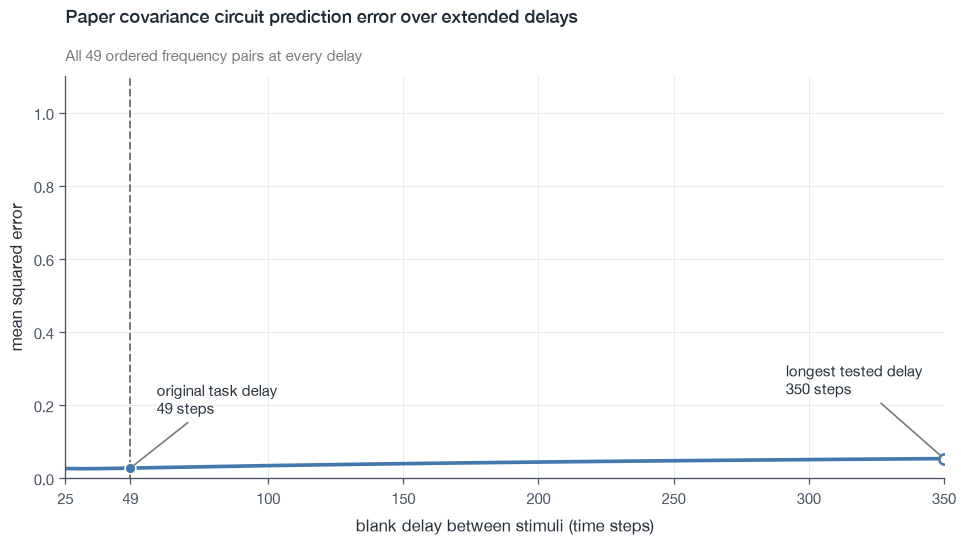

Paper circuit MSE, minimum to maximum: 0.025800–0.053339


In [24]:
paper_delay_mses = []
for delay in extended_delay_steps:
    delayed_inputs, _ = memory_task.make_fixed_delay_trials(
        memory_grid_pairs,
        second_start=memory_task.FIXED_FIRST_WINDOW[1] + int(delay),
    )
    delayed_outputs, _, _ = mean_field.simulate_gaussian_circuit(
        delayed_inputs,
        paper_names,
        paper_loading_mean,
        paper_loading_covariance,
        step_size=oscillatory_canonical.step_size,
    )
    delayed_decisions = analysis.decision_values(
        delayed_outputs,
        MEMORY_DECISION_STEPS,
    )
    delay_mse, _ = analysis.regression_metrics(
        delayed_decisions,
        memory_grid_targets,
    )
    paper_delay_mses.append(delay_mse)
paper_delay_mses = np.asarray(paper_delay_mses)

plotting.plot_delay_mse(
    extended_delay_steps,
    paper_delay_mses,
    title=(
        "Paper covariance circuit prediction error "
        "over extended delays"
    ),
    reference_delay=trained_delay_steps,
    reference_label="original task delay",
    annotation_delays=(extended_delay_steps[-1],),
    annotation_labels=("longest tested delay",),
    x_ticks=(25, 49, 100, 150, 200, 250, 300, 350),
    y_limit=delay_mse_y_limit,
)
plt.show()

print(
    "Paper circuit MSE, minimum to maximum:",
    f"{paper_delay_mses.min():.6f}–{paper_delay_mses.max():.6f}",
)

Unlike the trained RNN, the paper covariance circuit does not show
large oscillations in prediction error. Its MSE increases only gradually,
from approximately $0.026$ to $0.053$ across the full sweep. It is less
accurate at the original 49-step delay, but substantially more stable
across unseen delays. This supports the interpretation that its persistent
mode stores the first stimulus without requiring the decision to sample a
particular oscillatory phase.

## 3. Conclusions

- The rank-one RNN integrates noisy evidence in a two-dimensional
  $\operatorname{span}\{m,I\}$ subspace and stores the decision in two
  stable fixed points. Gaussian resamples and the mean-field circuit both
  retain 100% sign accuracy.
- Fixed-delay rank-two training produces a weakly expanding rotation.
  Its prediction error rises and falls with the test delay, showing a
  strong but incomplete recovery after roughly one full rotation. The
  fitted full-covariance circuit preserves this geometry and reaches
  $100\%$ direction accuracy, although its MSE remains above threshold.
- The paper covariance produces the intended persistent/transient
  geometry with $95.2\%$ direction accuracy, without introducing or
  training a second RNN. Its prediction error changes only gradually over
  unseen delays, trading some fixed-delay accuracy for much stronger delay
  generalization.